**VALIDATION USING BAG OF WORDS**

In [59]:
import pandas as pd

validation_df = pd.read_csv("twitter_validation.csv")

print(validation_df.shape)
print(validation_df.columns)
validation_df.head()

(1000, 4)
Index(['ID', 'TOPIC/PLATFORM', 'SENTIMENT', 'TEXT'], dtype='str')


,ID,TOPIC/PLATFORM,SENTIMENT,TEXT
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [60]:
validation_df["SENTIMENT"].value_counts()

SENTIMENT
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64

In [61]:
validation_df.dropna(
    subset=["TEXT", "SENTIMENT"],
    inplace=True
)

validation_df = validation_df[
    validation_df["SENTIMENT"] != "Irrelevant"
]

In [62]:
validation_df["SENTIMENT"].value_counts()

SENTIMENT
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64

In [63]:
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

[nltk_data] Downloading package punkt to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [64]:
stop_words = set(stopwords.words("english")) - {"not", "no", "nor"}

validation_df["CLEAN_TEXT"] = validation_df["TEXT"].apply(clean_text)

validation_df["TOKENS"] = validation_df["CLEAN_TEXT"].apply(
    word_tokenize
)

validation_df["NO_STOPWORDS"] = validation_df["TOKENS"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

lemmatizer = WordNetLemmatizer()

validation_df["LEMMATIZED"] = validation_df["NO_STOPWORDS"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

validation_df["LEMMATIZED_TEXT"] = validation_df["LEMMATIZED"].apply(
    lambda tokens: " ".join(tokens)
)



In [65]:
validation_df[["TEXT", "LEMMATIZED_TEXT", "SENTIMENT"]].head()

,TEXT,LEMMATIZED_TEXT,SENTIMENT
1,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon bos jeff bezos reject claim co...,Neutral
2,@Microsoft Why do I pay for WORD when it funct...,pay word function poorly chromebook,Negative
3,"CSGO matchmaking is so full of closet hacking,...",csgo matchmaking full closet hacking truly awf...,Negative
4,Now the President is slapping Americans in the...,president slapping american face really commit...,Neutral
5,Hi @EAHelp I’ve had Madeleine McCann in my cel...,hi ive madeleine mccann cellar past year littl...,Negative


In [66]:
X_validation = validation_df["LEMMATIZED_TEXT"]
y_validation = validation_df["SENTIMENT"]

In [67]:
import joblib

bow = joblib.load("bow_Vectorizer.pkl")
best_model = joblib.load("bow_sentiment_model.pkl")

In [68]:
X_validation_bow = bow.transform(X_validation)

In [69]:
print(X_validation_bow.shape)

(828, 96802)


In [70]:
validation_pred = best_model.predict(X_validation_bow)

In [71]:
print(validation_pred[:20])

['Neutral' 'Negative' 'Negative' 'Neutral' 'Negative' 'Positive'
 'Positive' 'Positive' 'Negative' 'Positive' 'Positive' 'Negative'
 'Neutral' 'Negative' 'Positive' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive']


In [72]:
pd.Series(validation_pred).value_counts()

Neutral     283
Positive    283
Negative    262
Name: count, dtype: int64

**Validation Metrics**

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

validation_accuracy = accuracy_score(
    y_validation,
    validation_pred
)

validation_precision = precision_score(
    y_validation,
    validation_pred,
    average="weighted"
)

validation_recall = recall_score(
    y_validation,
    validation_pred,
    average="weighted"
)

validation_f1 = f1_score(
    y_validation,
    validation_pred,
    average="weighted"
)

print("Validation Results")
print("-------------------")
print("Accuracy :", validation_accuracy)
print("Precision:", validation_precision)
print("Recall   :", validation_recall)
print("F1-Score :", validation_f1)

Validation Results
-------------------
Accuracy : 0.9758454106280193
Precision: 0.9760205449204474
Recall   : 0.9758454106280193
F1-Score : 0.9758734149885406


In [74]:
from sklearn.metrics import classification_report

print(classification_report(
    y_validation,
    validation_pred
))

              precision    recall  f1-score   support

    Negative       0.99      0.97      0.98       266
     Neutral       0.98      0.97      0.98       285
    Positive       0.96      0.98      0.97       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



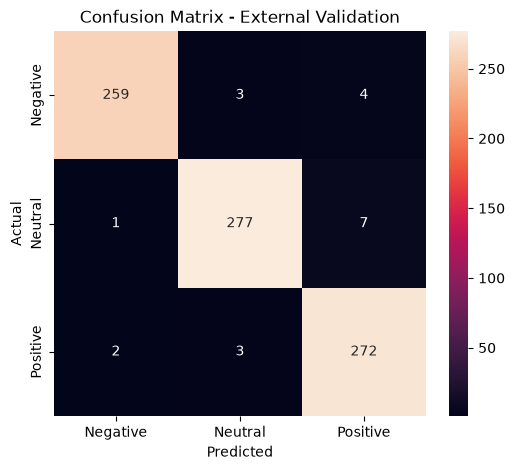

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_validation,
    validation_pred,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - External Validation")

plt.show()

In [76]:
import os

print(os.path.exists("bow_sentiment_model.pkl"))
print(os.path.exists("bow_Vectorizer.pkl"))

True
True


**VALIDATION USING TF-IDF**

In [77]:
from nltk.stem import SnowballStemmer

snowball = SnowballStemmer("english")

validation_df["SNOWBALL_STEMMED"] = validation_df["NO_STOPWORDS"].apply(
    lambda tokens: [snowball.stem(word) for word in tokens]
)

validation_df["SNOWBALL_TEXT"] = validation_df["SNOWBALL_STEMMED"].apply(
    lambda tokens: " ".join(tokens)
)

In [78]:
X_validation_tfidf = validation_df["SNOWBALL_TEXT"]
y_validation_tfidf = validation_df["SENTIMENT"]

In [79]:
import joblib

tfidf = joblib.load("tfidf_vectorizer.pkl")
tfidf_model = joblib.load("tfidf_sentiment_model.pkl")

X_validation_tfidf = tfidf.transform(
    X_validation_tfidf
)

tfidf_validation_pred = tfidf_model.predict(
    X_validation_tfidf
)

In [80]:
tfidf_validation_accuracy = accuracy_score(
    y_validation_tfidf,
    tfidf_validation_pred
)

tfidf_validation_precision = precision_score(
    y_validation_tfidf,
    tfidf_validation_pred,
    average="weighted"
)

tfidf_validation_recall = recall_score(
    y_validation_tfidf,
    tfidf_validation_pred,
    average="weighted"
)

tfidf_validation_f1 = f1_score(
    y_validation_tfidf,
    tfidf_validation_pred,
    average="weighted"
)

print("TF-IDF External Validation Results")
print("-----------------------------------")
print("Accuracy :", tfidf_validation_accuracy)
print("Precision:", tfidf_validation_precision)
print("Recall   :", tfidf_validation_recall)
print("F1-Score :", tfidf_validation_f1)

TF-IDF External Validation Results
-----------------------------------
Accuracy : 0.961352657004831
Precision: 0.962815269263691
Recall   : 0.961352657004831
F1-Score : 0.9615204481346619


In [81]:
print(classification_report(
    y_validation_tfidf,
    tfidf_validation_pred
))

              precision    recall  f1-score   support

    Negative       0.92      0.98      0.95       266
     Neutral       0.99      0.96      0.97       285
    Positive       0.98      0.94      0.96       277

    accuracy                           0.96       828
   macro avg       0.96      0.96      0.96       828
weighted avg       0.96      0.96      0.96       828



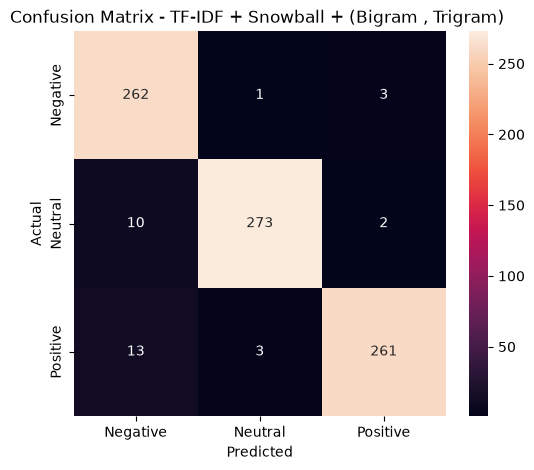

In [82]:
cm_tfidf = confusion_matrix(
    y_validation_tfidf,
    tfidf_validation_pred,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TF-IDF + Snowball + (Bigram , Trigram) ")

plt.show()

In [83]:
print(os.path.exists("tfidf_sentiment_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))

True
True


In [84]:
print(os.path.exists("bow_sentiment_model.pkl"))
print(os.path.exists("bow_Vectorizer.pkl"))

True
True


**FINAL COMPARISON BETWEEN TF-IDF Vs BoW**

In [85]:
comparison = pd.DataFrame({
    "Model": ["Bag of Words", "TF-IDF"],
    "Accuracy": [validation_accuracy, tfidf_validation_accuracy],
    "Precision": [validation_precision, tfidf_validation_precision],
    "Recall": [validation_recall, tfidf_validation_recall],
    "F1-Score": [validation_f1, tfidf_validation_f1]
})

print("External Validation Comparison")
print(comparison)

External Validation Comparison
          Model  Accuracy  Precision    Recall  F1-Score
0  Bag of Words  0.975845   0.976021  0.975845  0.975873
1        TF-IDF  0.961353   0.962815  0.961353  0.961520


In [86]:
comparison_percentage = comparison.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison_percentage[column] = (
        comparison_percentage[column] * 100
    ).round(2).astype(str) + "%"

print(comparison_percentage)

          Model Accuracy Precision  Recall F1-Score
0  Bag of Words   97.58%     97.6%  97.58%   97.59%
1        TF-IDF   96.14%    96.28%  96.14%   96.15%


**Your final model test accuracy is 90.27%.**

**Model:** Logistic Regression

**Feature extraction:** Bag of Words

**Preprocessing:** Lemmatization

**N-gram:** Unigram + Bigram

**After GridSearchCV tuning:** 90.27%

**External validation accuracy:** 97.58%

**External validation precision:** 97.60%

**External validation recall:** 97.58%

**External validation F1-Score:** 97.59%
